# Introduction to Colab
In the previous notebook you learned some Markdown language. Now we are going to try out some Python code and make some plots using data we read from a url.

## You can quickly create simulated data within jupyter notebook and do simple plots.
Here we create a normal distribution probability density plot. Notice that the output plot is quick and dirty as there are no axis labels, no title, default color and backgrounds, etc. As the semester progress, we will learn to change the details on the plot to make it easier to communicate the output to our audience.

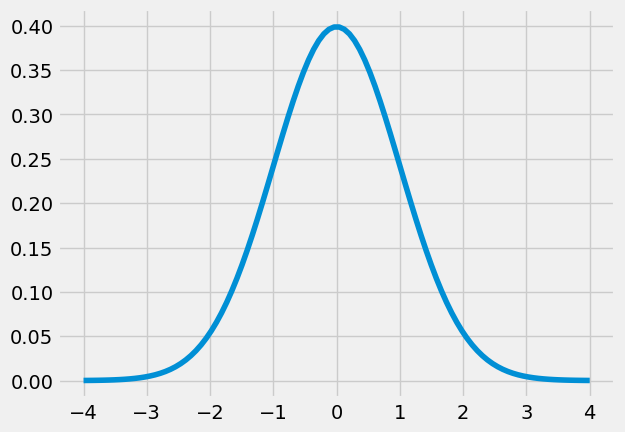

In [1]:
'''Normal distribution probability density plot'''
### Import your libraries/packages
import numpy as np
import scipy.stats as stats

### When using the 'inline' backend, your matplotlib graphs will be included in your notebook, next to the code.
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight') #This is a matplotlib style sheet

mu = 0 # mean
std = 1 # variance

## Return 100 evenly spaced numbers over a specified interval (between -4 and 4)
x = np.linspace(start=-4, stop=4, num=100)

## A probability density function of a normal continuous random distribution
y = stats.norm.pdf(x, mu, std)
plots.plot(x, y)
# plots.show()

### We can read in input data from a url and do some analysis

---



In [4]:
'''Read in input data from url'''
### Import your libraries/packages
# !pip install datascience # Install the datascience library
from datascience import Table
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
from urllib.request import urlopen
import re

### Write a function to take in url, read it and return data
def read_url(url):
    return re.sub('\s+', ' ', urlopen(url).read().decode())


### Let's quickly read the book and count number of instances of characters
huck_finn_url = 'https://www.inferentialthinking.com/data/huck_finn.txt'
huck_finn_text = read_url(huck_finn_url)
huck_finn_chapters = huck_finn_text.split('CHAPTER ')[44:] # there are 44 instance of CHAPTER before the first chapter

# Display the chapters of Huckleberry Finn in a table.
Table().with_column('Chapters', huck_finn_chapters)

## Count the number of occurences of 'Tom' in each chapter
# print("Number of occurences of Tom per chapter ", np.char.count(huck_finn_chapters, 'Tom'))

## Create a table with the counts of three names for each chapter: 'Tom', 'Jim', and 'Huck'.
counts = Table().with_columns([
    'Tom', np.char.count(huck_finn_chapters, 'Tom'),
    'Jim', np.char.count(huck_finn_chapters, 'Jim'),
    'Huck', np.char.count(huck_finn_chapters, 'Huck'),
])

## To see the count table, you can call the table and don't need to use print
counts

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_672/3406862239.py:12: SyntaxWarning: invalid escape sequence '\s'
  return re.sub('\s+', ' ', urlopen(url).read().decode())


Tom,Jim,Huck
6,0,3
24,16,2
5,0,2
0,8,1
0,0,0
0,0,2
2,0,0
2,22,5
0,11,1
0,19,0


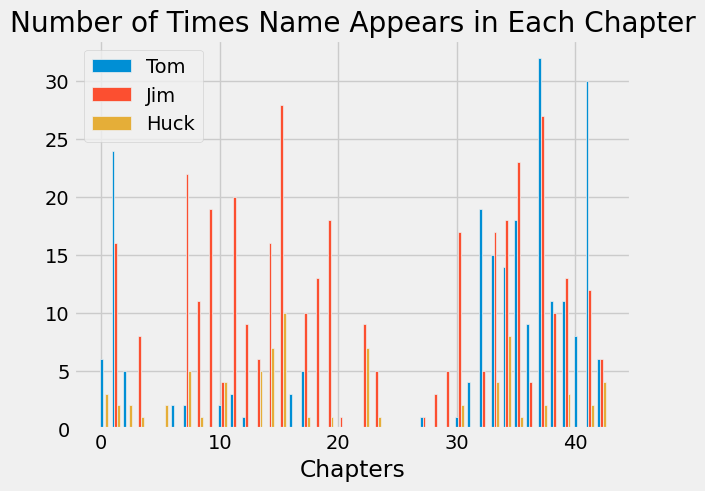

In [49]:
'''Plot the character counts of each character for 43 chapters'''
## Import matplotlib
import matplotlib.pyplot as plt

## Make a simple bar plot of each characters counts
chapter_numbers = range(1, 44)

## Make a multiple bar plot for each category by shifting the x-axis position
# allowing multiple datasets to be displayed side by side for comparison

barWidth = 0.24
# fig = plt.subplots(figsize =(12, 8))
br1 = np.arange(len(chapter_numbers))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]

plt.bar(br1, counts.column('Tom'), label='Tom', width=barWidth)
plt.bar(br2, counts.column('Jim'), label='Jim', width=barWidth)
plt.bar(br3, counts.column('Huck'), label='Huck', width=barWidth)

## Plot and add a title and x-axis label to the plot. Chapter numbers are on the x-axis
plt.legend()
plots.title('Number of Times Name Appears in Each Chapter')
plt.xlabel('Chapters')
plt.show()

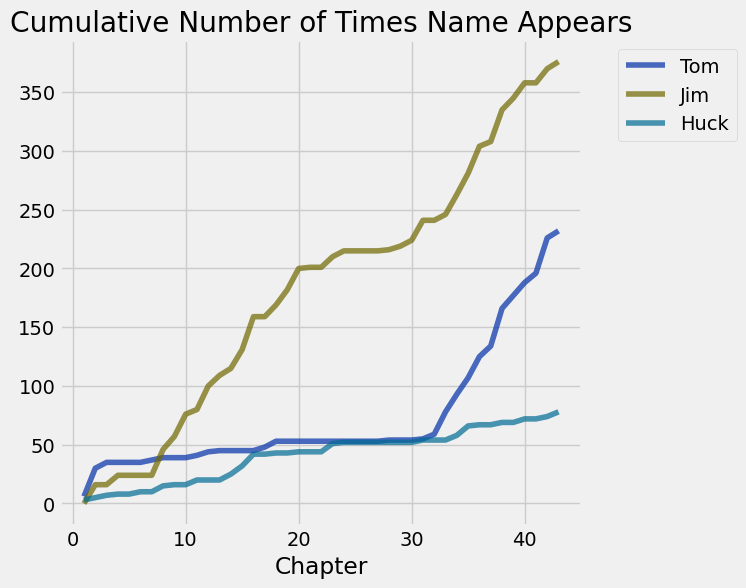

In [5]:
'''Plot the cumulative counts for 43 chapters:'''
## A cumulative count plot will ask how many times in Chapter 1, then how many times in Chapter 1 and 2, and so on.

%matplotlib inline
## Table method references: https://www.data8.org/datascience/tables.html

## Create a new table and add the chapter numbers
cum_counts = Table().with_column('Chapter', np.arange(1, 44, 1))

## For loop use to iterate over the character names
for character_name in counts.labels:
  ## Add a column to the new table with each character's cumulative appearances
  cum_counts = cum_counts.with_column(
    character_name, counts.column(character_name).cumsum())
  # print(cum_counts)

## Plot and add a title to the plot. Chapter numbers are on the x-axis
cum_counts.plot(column_for_xticks=0)
plots.title('Cumulative Number of Times Name Appears')
plots.show()

#CL2.1
Now it is your turn. Try to do some word counting from the chapters in "The Little Women".  
Do the same thing as the above example for these 5 names: 'Amy', 'Beth', 'Jo', 'Laurie', 'Meg'.  

In [50]:
'''Count character names in "The Little Women"'''
### url to "The Little Women" text
little_women_url = 'https://www.inferentialthinking.com/data/little_women.txt'
little_women_text = read_url(little_women_url)
little_women_chapters = little_women_text.split('CHAPTER ')[1:]

# Plot a bar plot and a cumulative counts for the 47 chapters

# Your code here

# CL2.2
Let's work on interpreting the plots. Learning to create a plot can be simple enough in Python as there are many libraries and documentation available. One of the challenges in Data visualization is determining why you want to select one type of visualization over another.
Look at the output plots from CL2.1 and compare the bar plot to the cumulative count plot. In your groups, discuss the following:

*   What are the differences versus similarity between the two plots?
*   What type of question would you be answering for each of the plot?
*   What type of problem or questions would you be answering where you would choose a cumulative plot over a bar plot?

*Place your answers in the Google Doc*